In [185]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [186]:
from datetime import date

from aquacrop import AquaCrop, Crop, Soil, Weather, InitialConditions
from aquacrop.templates import manuloa_co2_records

from aquacrop_slovenia import config
from aquacrop_slovenia.prepare_weather import load_station_weather
from aquacrop_slovenia.crop_maize_defaults import maize_params
from aquacrop_slovenia.soil_jablje_defaults import jablje_soil_layers,jablje_curve_number,jablje_readily_evaporable_water
from aquacrop_slovenia.management_defaults import optimal_management
from aquacrop_slovenia.intial_conditions_defaults import intial_cond_params

In [187]:
# Set up working directory for outputs
output_dir = config.MODELS_DIR / "testing"

plant and end dates are set to be the same every year - TODO TEMPORARY!!!

We exclude 2017 since we dont have ET data for most of the year

In [188]:
#year = 1993
simulation_periods = [
    {
        "start_date": date(year, 1, 1),
        "end_date": date(year, 10, 10), # TODO temporary
        "planting_date": date(year, 5, 3), # TODO temporary
        "is_seeding_year": True,
    }
#]
for year in range(1993, 2024) if year != 2017]

In [189]:
jablje_temperatures, jablje_eto, jablje_rain = load_station_weather(8)

In [190]:
jablje_weather = Weather(
    location="Jablje",
    temperatures=jablje_temperatures,
    eto_values=jablje_eto,
    rainfall_values=jablje_rain,
    record_type=1,
    first_day=1,
    first_month=1,
    first_year=1993,
    co2_records=manuloa_co2_records
)

In [191]:
jablje_maize = Crop(
    name="Jablje Maize",
    description="Jablje maize uncalibrated",
    params=maize_params
)

In [192]:
jablje_soil = Soil(
    name="Jablje Soil",
    description="Jablje silt loam soil uncalibrated",
    soil_layers=jablje_soil_layers,
    curve_number=jablje_curve_number,
    readily_evaporable_water=jablje_readily_evaporable_water
)

In [193]:
default_initial_conditions = InitialConditions(
    name="DefaultInitialConditions",
    description="Default initial conditions with AquaCrop calculated defaults",
    params=intial_cond_params
)

In [194]:
# Create AquaCrop simulation
simulation = AquaCrop(
    simulation_periods=simulation_periods,
    crop=jablje_maize,
    soil=jablje_soil,
    management=optimal_management,
    initial_conditions=default_initial_conditions,
    climate=jablje_weather,
    working_dir=output_dir,
    need_daily_output=True,
    need_seasonal_output=True,
    need_harvest_output=False,
    need_evaluation_output=False
)

In [195]:
# Run the simulation
results = simulation.run()

Setting up working directory at: C:\Users\rokuk\Documents\Code\aquacrop-slovenia\models\testing
Running AquaCrop simulation with project file: C:\Users\rokuk\Documents\Code\aquacrop-slovenia\models\testing\LIST\PROJECT.PRM
Detected platform: windows (AMD64)
Looking for executable at: C:\Users\rokuk\Documents\Code\aquacrop-slovenia\.venv\Lib\site-packages\model\windows\aquacrop.exe
AquaCrop executable not found at C:\Users\rokuk\Documents\Code\aquacrop-slovenia\.venv\Lib\site-packages\model\windows\aquacrop.exe. Downloading from https://github.com/KUL-RSDA/AquaCrop/releases/download/v7.2/aquacrop-7.2-x86_64-windows.zip
Extracted AquaCrop executable to C:\Users\rokuk\Documents\Code\aquacrop-slovenia\.venv\Lib\site-packages\model\windows\aquacrop-7.2-x86_64-windows\aquacrop.exe
Using AquaCrop executable: C:\Users\rokuk\Documents\Code\aquacrop-slovenia\models\testing\aquacrop.exe
AquaCrop simulation completed successfully
Parsing simulation results...
Results successfully parsed


In [196]:
results["season"]

,RunNr,Day1,Month1,Year1,Rain,ETo,GD,CO2,Irri,Infilt,...,HI,Y(dry),Y(fresh),WPet,Bin,Bout,DayN,MonthN,YearN,Project
0,1,1,1,1993,765.3,723.8,1461.8,357.21,0.0,663.2,...,5.2,1.356,1.506,0.36,0.0,0.0,10,10,1993,PROJECT.PRM
1,2,1,1,1994,1019.4,706.5,1567.8,358.96,0.0,909.9,...,5.3,1.531,1.701,0.33,0.0,0.0,10,10,1994,PROJECT.PRM
2,3,1,1,1995,1199.6,647.7,1335.5,360.97,0.0,990.3,...,4.2,0.988,1.098,0.26,0.0,0.0,10,10,1995,PROJECT.PRM
3,4,1,1,1996,1087.0,603.8,1323.1,362.74,0.0,895.1,...,4.1,0.960,1.067,0.28,0.0,0.0,10,10,1996,PROJECT.PRM
4,5,1,1,1997,740.0,683.6,1437.8,363.88,0.0,684.3,...,4.8,1.369,1.521,0.33,0.0,0.0,10,10,1997,PROJECT.PRM
5,6,1,1,1998,1068.3,671.4,1545.9,366.84,0.0,913.9,...,5.9,1.631,1.812,0.44,0.0,0.0,10,10,1998,PROJECT.PRM
6,7,1,1,1999,1089.3,642.0,1562.4,368.54,0.0,938.1,...,6.2,1.870,2.077,0.43,0.0,0.0,10,10,1999,PROJECT.PRM
7,8,1,1,2000,869.7,704.3,1541.4,369.71,0.0,780.4,...,5.1,1.428,1.587,0.33,0.0,0.0,10,10,2000,PROJECT.PRM
8,9,1,1,2001,1054.2,661.7,1491.7,371.32,0.0,892.9,...,5.2,1.395,1.550,0.33,0.0,0.0,10,10,2001,PROJECT.PRM
9,10,1,1,2002,865.7,643.0,1492.1,373.45,0.0,783.1,...,6.2,1.737,1.930,0.43,0.0,0.0,10,10,2002,PROJECT.PRM


<Axes: xlabel='Year1'>

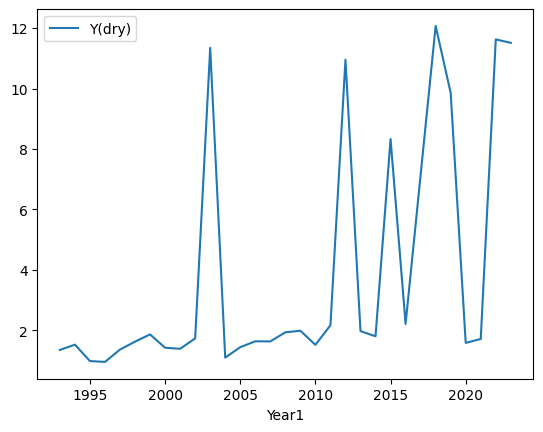

In [197]:
results["season"].plot(x="Year1", y="Y(dry)")

In [198]:
results["day"]

,Day,Month,Year,DAP,Stage,WC(2.30),Rain,Irri,Surf,Infilt,...,9_1,ECe10,ECe11,ECe12,Rain_1,ETo,Tmin,Tavg,Tmax,CO2
0,1,1,1993,-9,0,758.7,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
1,2,1,1993,-9,0,758.1,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
2,3,1,1993,-9,0,757.4,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
3,4,1,1993,-9,0,757.1,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
4,5,1,1993,-9,0,756.9,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278,6,10,1993,157,4,763.3,2.4,0.0,0.0,2.4,...,None,None,None,None,None,None,None,None,None,None
279,7,10,1993,158,4,787.7,47.0,0.0,0.0,27.4,...,None,None,None,None,None,None,None,None,None,None
280,8,10,1993,159,4,783.2,7.3,0.0,0.0,7.0,...,None,None,None,None,None,None,None,None,None,None
281,9,10,1993,160,4,790.2,26.0,0.0,0.0,19.2,...,None,None,None,None,None,None,None,None,None,None


<Axes: >

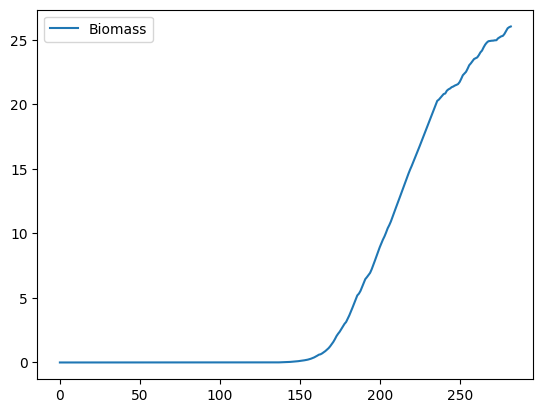

In [199]:
results["day"].plot(y="Biomass")

<Axes: >

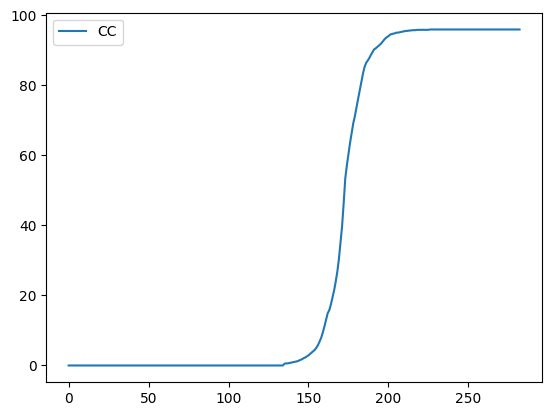

In [200]:
results["day"].plot(y="CC")

<Axes: >

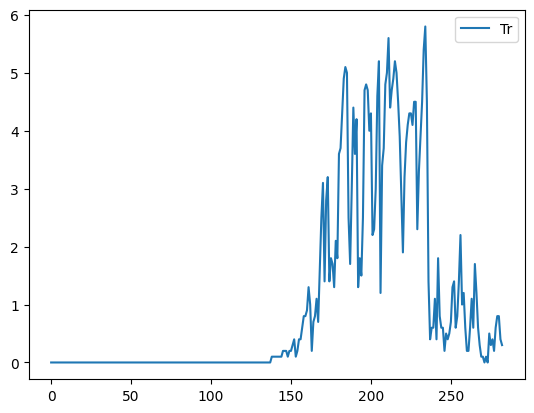

In [201]:
results["day"].plot(y="Tr")

<Axes: >

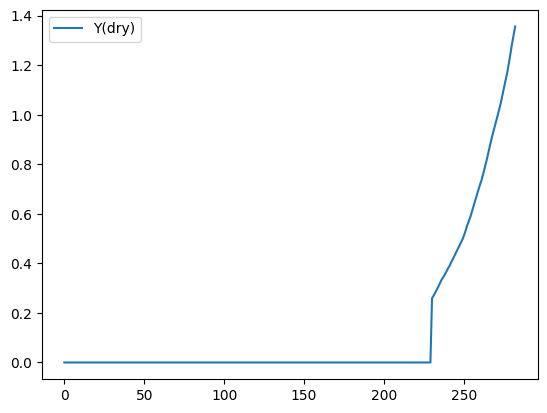

In [202]:
results["day"].plot(y="Y(dry)")

In [203]:
import pandas as pd
from aquacrop_slovenia.gdd import a as calc_gdd

base_temp = maize_params['base_temp']
upper_temp = maize_params['upper_temp']

df_weather = pd.read_pickle(config.PROCESSED_WEATHER_DIR / "station_8.pkl")

gdd_by_year = (
    df_weather
    .assign(gdd=df_weather.apply(lambda r: calc_gdd(r["tmax"], r["tmin"], base_temp, upper_temp), axis=1))
    .groupby(df_weather["datum"].dt.year)["gdd"]
    .sum()
    .rename_axis("year")
    .rename("gdd")
)
gdd_by_year

year
1993    1524.15
1994    1594.95
1995    1400.80
1996    1393.60
1997    1464.55
1998    1587.55
1999    1649.60
2000    1655.40
2001    1565.35
2002    1588.85
2003    1766.65
2004    1480.05
2005    1546.20
2006    1586.85
2007    1614.85
2008    1621.85
2009    1705.90
2010    1537.40
2011    1712.45
2012    1794.95
2013    1696.15
2014    1726.55
2015    1735.20
2016    1689.20
2017    1689.15
2018    1985.15
2019    1759.35
2020    1656.80
2021    1600.40
2022    1906.65
2023    1857.95
Name: gdd, dtype: float64

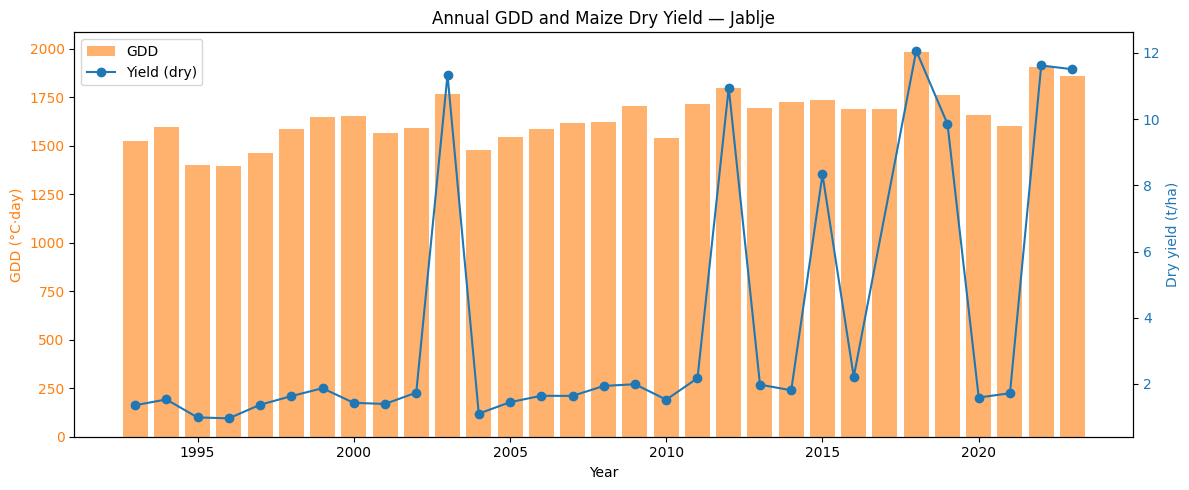

In [204]:
import matplotlib.pyplot as plt

season = results["season"].set_index("Year1")

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(gdd_by_year.index, gdd_by_year.values, color="tab:orange", alpha=0.6, label="GDD")
ax1.set_ylabel("GDD (°C·day)", color="tab:orange")
ax1.tick_params(axis="y", labelcolor="tab:orange")

ax2 = ax1.twinx()
ax2.plot(season.index, season["Y(dry)"], marker="o", color="tab:blue", label="Yield (dry)")
ax2.set_ylabel("Dry yield (t/ha)", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

ax1.set_xlabel("Year")
plt.title("Annual GDD and Maize Dry Yield — Jablje")
plt.tight_layout()
plt.show()